In [ ]:
spark.stop()

In [1]:
# ** This cell is needed since we are not in the src directory **
import sys 
import os
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

import sys
sys.path.append("/Users/admin/eeg-ds004504/")


In [2]:
from config_handler import initiate_config, load_config

initiate_config()

{'data_path': '/Users/admin/eeg-ds004504',
 'derivatives': True,
 'freqBands': {'Alpha': [8, 12],
  'Beta': [12, 30],
  'Delta': [0.5, 4],
  'Theta': [4, 8],
  'custom1': [9, 11]},
 'method': 'welch',
 'stepSize': 3.0,
 'windowLength': 3.0}

In [3]:
print(load_config())

{'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 3.0, 'windowLength': 3.0}


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd

In [5]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [6]:
# creating the ultimate most optimised spark session ever muwahaha
import os
from pyspark.sql import SparkSession

# Set Java options for the JVM running Spark
# -Xmx12g : Sets the maximum heap size to 12GB
# -Xms4g : Sets the initial heap size to 4GB to avoid resizing overhead
os.environ["_JAVA_OPTIONS"] = "-Xmx16g -Xms8g"

# Build Spark session with memory, parallelism, and network settings
spark = (
    SparkSession.builder 
    # Application name shown in Spark UI
    .appName("EEG_Analysis") 

    # SPARK DIRECTORY FOR THREADS / PERSIST
    
    # Use all available logical cores or specify a number
    # "local[*]" uses all available cores, "local[12]" limits to 12 threads
    .config("spark.master", "local[12]") \

    # Executor memory: how much memory each Spark worker can use
    .config("spark.executor.memory", "8g") \

    # Driver memory: memory available to the Spark driver (main Python process)
    .config("spark.driver.memory", "8g") \
    
    # THIS IS WHERE SPARK WILL PUT ITS TEMPERARY VARIABLES 
    # .config("spark.local.dir", os.path.expanduser("~/external-spark-tmp"))

    # Number of shuffle partitions (e.g., after groupBy, join, etc.)
    # Lower this in local mode to reduce overhead (default is 200)
    .config("spark.sql.shuffle.partitions", "12") \

    # Default number of partitions in operations like parallelize
    .config("spark.default.parallelism", "12") \

    # Maximum size (in MB) allowed for any RPC message (e.g., large UDF closures or data broadcasts)
    .config("spark.rpc.message.maxSize", "512") \

    # prevent breaking pipes 
    .config("spark.reducer.maxReqsInFlight", "1") \
    .config("spark.shuffle.io.preferDirectBufs", "false") \
    .config("spark.shuffle.file.buffer", "32k") \
    
    # Required for avoiding binding issues on some MacOS environments
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") 
    .getOrCreate()
)

print("New Spark session created successfully")

Picked up _JAVA_OPTIONS: -Xmx16g -Xms8g
Picked up _JAVA_OPTIONS: -Xmx16g -Xms8g
25/09/07 01:19:11 WARN Utils: Your hostname, Mac-mini.local resolves to a loopback address: 127.0.0.1; using 192.168.1.172 instead (on interface en1)
25/09/07 01:19:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/07 01:19:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


New Spark session created successfully


In [7]:
def reload_my_modules():
    import importlib
    import populate_schemas
    import feature_extraction
    import schema_definition
    importlib.reload(populate_schemas)
    importlib.reload(feature_extraction)
    importlib.reload(schema_definition)

reload_my_modules()


from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema

sc = spark.sparkContext # we pass udf/udtf's (user defind functions and user defined table functions) to spark so it can access them

# Making all necessary modules available to spark
try: 
    # oh btw spark is werid about not finding the config but it always finds it somehow not sure how that works not going to look rn tbh
    # ^ so feature_extraction has extra print statements
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "config_handler.py"))
    print("Added config_handler.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Config not found in feature_extraction.py
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 3.0, 'windowLength': 3.0}
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 3.0, 'windowLength': 3.0}
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 3.0, 'windowLength': 3.0}
Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context
Added config_h

In [8]:
 parquet_direcotry = "/Volumes/CrucialX6/Home/projects/eeg-ds004504/notebooks"

In [9]:
alz_df_spark = spark.read.parquet(f"{parquet_direcotry}/features_alz_extra_features_Sep07_0031.parquet")
cntrl_df_spark = spark.read.parquet(f"{parquet_direcotry}/features_cntrl_extra_features_Sep07_0031.parquet")
ftd_df_spark = spark.read.parquet(f"{parquet_direcotry}/features_ftd_extra_features_Sep07_0031.parquet")

In [10]:
# rename for useability, I wanted it to be clear that the dataframes are spark.sql types when we create them above
alz_df = alz_df_spark
cntrl_df = cntrl_df_spark
ftd_df = ftd_df_spark

In [11]:
alz_df.show()

+---------+-------+---------+--------+----------------+------------+----------+
|SubjectID|EpochID|Electrode|WaveBand|     FeatureName|FeatureValue|table_type|
+---------+-------+---------+--------+----------------+------------+----------+
|  sub-013|   ep-0|      Fp1|    NULL|      TotalPower| 0.011235955| electrode|
|  sub-013|   ep-0|      Fp1|    NULL|     TotalEnergy|  0.14489196| electrode|
|  sub-013|   ep-0|      Fp1|    NULL| SpectralEntropy|    3.733468| electrode|
|  sub-013|   ep-0|      Fp1|    NULL|  HjorthActivity|1.2903898E-9| electrode|
|  sub-013|   ep-0|      Fp1|    NULL|  HjorthMobility|  0.03364996| electrode|
|  sub-013|   ep-0|      Fp1|    NULL|HjorthComplexity|    8.939166| electrode|
|  sub-013|   ep-0|      Fp1|    NULL|     HjorthIndex|   1503.7643| electrode|
|  sub-013|   ep-0|      Fp1|   Alpha|           Power| 0.002687694|      band|
|  sub-013|   ep-0|      Fp1|   Alpha| SpectralEntropy|   2.9079826|      band|
|  sub-013|   ep-0|      Fp1|   Alpha|  

# Data Processing and Dimensionality Reduction

In [12]:
# give each its respective labels
from pyspark.sql.functions import lit
ftd_df = ftd_df.withColumn("label", lit(2)).repartition(16).persist()
alz_df = alz_df.withColumn("label", lit(1)).repartition(16).persist()
cntrl_df = cntrl_df.withColumn("label", lit(0)).repartition(16).persist()

In [13]:
full_df = alz_df.unionByName(cntrl_df).unionByName(ftd_df)

In [14]:
# Split based on feature type
from pyspark.sql.functions import col

band_df = full_df.filter(col("table_type") == "band")
channel_df = full_df.filter(col("table_type") == "electrode")
epoch_df = full_df.filter(col("table_type") == "epoch")

In [15]:
from pyspark.sql.functions import concat_ws

# Band-level: Electrode_WaveBand_Feature
band_df = band_df.withColumn("pivot", concat_ws("_", "Electrode", "WaveBand", "FeatureName")).repartition(16).persist()

# Channel-level: Electrode_Feature
channel_df = channel_df.withColumn("pivot", concat_ws("_", "Electrode", "FeatureName")).repartition(16).persist()

# Epoch-level: just FeatureName
epoch_df = epoch_df.withColumn("pivot", col("FeatureName")).repartition(16).persist()


In [16]:
from pyspark.sql.functions import first

# Pivot band-level features
band_pivot = band_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))

# Pivot channel-level features
channel_pivot = channel_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))

# Pivot epoch-level features
epoch_pivot = epoch_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))

In [17]:
from functools import reduce



full_df = reduce(
    lambda df1, df2: df1.join(df2, on=["SubjectID", "EpochID", "label"], how="outer"),
     [band_pivot, channel_pivot, epoch_pivot]# band_pivot, channel_pivot, epoch_pivot]
).fillna(0.0)
full_df.repartition(16).persist()

25/09/07 01:19:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


DataFrame[SubjectID: string, EpochID: string, label: int, C3_Alpha_HjorthComplexity: float, C3_Alpha_HjorthIndex: float, C3_Alpha_HjorthMobility: float, C3_Alpha_Power: float, C3_Alpha_SpectralEntropy: float, C3_Beta_HjorthComplexity: float, C3_Beta_HjorthIndex: float, C3_Beta_HjorthMobility: float, C3_Beta_Power: float, C3_Beta_SpectralEntropy: float, C3_Delta_HjorthComplexity: float, C3_Delta_HjorthIndex: float, C3_Delta_HjorthMobility: float, C3_Delta_Power: float, C3_Delta_SpectralEntropy: float, C3_Theta_HjorthComplexity: float, C3_Theta_HjorthIndex: float, C3_Theta_HjorthMobility: float, C3_Theta_Power: float, C3_Theta_SpectralEntropy: float, C3_custom1_HjorthComplexity: float, C3_custom1_HjorthIndex: float, C3_custom1_HjorthMobility: float, C3_custom1_Power: float, C3_custom1_SpectralEntropy: float, C4_Alpha_HjorthComplexity: float, C4_Alpha_HjorthIndex: float, C4_Alpha_HjorthMobility: float, C4_Alpha_Power: float, C4_Alpha_SpectralEntropy: float, C4_Beta_HjorthComplexity: float

In [18]:
full_df.repartition(16).persist()

25/09/07 01:19:35 WARN CacheManager: Asked to cache already cached data.


DataFrame[SubjectID: string, EpochID: string, label: int, C3_Alpha_HjorthComplexity: float, C3_Alpha_HjorthIndex: float, C3_Alpha_HjorthMobility: float, C3_Alpha_Power: float, C3_Alpha_SpectralEntropy: float, C3_Beta_HjorthComplexity: float, C3_Beta_HjorthIndex: float, C3_Beta_HjorthMobility: float, C3_Beta_Power: float, C3_Beta_SpectralEntropy: float, C3_Delta_HjorthComplexity: float, C3_Delta_HjorthIndex: float, C3_Delta_HjorthMobility: float, C3_Delta_Power: float, C3_Delta_SpectralEntropy: float, C3_Theta_HjorthComplexity: float, C3_Theta_HjorthIndex: float, C3_Theta_HjorthMobility: float, C3_Theta_Power: float, C3_Theta_SpectralEntropy: float, C3_custom1_HjorthComplexity: float, C3_custom1_HjorthIndex: float, C3_custom1_HjorthMobility: float, C3_custom1_Power: float, C3_custom1_SpectralEntropy: float, C4_Alpha_HjorthComplexity: float, C4_Alpha_HjorthIndex: float, C4_Alpha_HjorthMobility: float, C4_Alpha_Power: float, C4_Alpha_SpectralEntropy: float, C4_Beta_HjorthComplexity: float

In [19]:
fraction = 0.2  # fraction to KEEP
seed = 42       # random seed for reproducibility (any integer)
full_df = full_df.sample(withReplacement=False, fraction=fraction, seed=seed)

In [20]:
full_df.createOrReplaceTempView("full_df")   # now SQL can SELECT FROM epochs

In [21]:
train_df = spark.sql("""
WITH ranked AS (
  SELECT *,
         ntile(5) OVER (PARTITION BY SubjectID ORDER BY rand(42)) AS bucket
  FROM full_df
)
SELECT * FROM ranked WHERE bucket <= 4
""")

test_df = spark.sql("""
WITH ranked AS (
  SELECT *,
         ntile(5) OVER (PARTITION BY SubjectID ORDER BY rand(42)) AS bucket
  FROM full_df
)
SELECT * FROM ranked WHERE bucket = 5
""")

In [22]:
print("all:", full_df.count(),
      "\ntrain:", train_df.count(),
      "\ntest:", test_df.count())

overlap = (train_df.select("SubjectID","EpochID").intersect(
           test_df.select("SubjectID","EpochID"))).count()
print("overlap rows:", overlap)

all: 4577 
train: 3697 
test: 880


[Stage 272:>                                                        (0 + 6) / 6]

overlap rows: 0


In [23]:
# reducing number of feature cols ... 

# ! Note lowering number of feature cols
... older_dataset_feature_cols is a list of feature columns used in features_alz_extra_features_Apr19_2141 before we expanded it to much more features which crashes locally
This has 

In [24]:
older_dataset_feature_cols=['C3_Alpha_Power',
 'C3_Beta_Power',
 'C3_Delta_Power',
 'C3_Theta_Power',
 'C3_custom1_Power',
 'C4_Alpha_Power',
 'C4_Beta_Power',
 'C4_Delta_Power',
 'C4_Theta_Power',
 'C4_custom1_Power',
 'Cz_Alpha_Power',
 'Cz_Beta_Power',
 'Cz_Delta_Power',
 'Cz_Theta_Power',
 'Cz_custom1_Power',
 'F3_Alpha_Power',
 'F3_Beta_Power',
 'F3_Delta_Power',
 'F3_Theta_Power',
 'F3_custom1_Power',
 'F4_Alpha_Power',
 'F4_Beta_Power',
 'F4_Delta_Power',
 'F4_Theta_Power',
 'F4_custom1_Power',
 'F7_Alpha_Power',
 'F7_Beta_Power',
 'F7_Delta_Power',
 'F7_Theta_Power',
 'F7_custom1_Power',
 'F8_Alpha_Power',
 'F8_Beta_Power',
 'F8_Delta_Power',
 'F8_Theta_Power',
 'F8_custom1_Power',
 'Fp1_Alpha_Power',
 'Fp1_Beta_Power',
 'Fp1_Delta_Power',
 'Fp1_Theta_Power',
 'Fp1_custom1_Power',
 'Fp2_Alpha_Power',
 'Fp2_Beta_Power',
 'Fp2_Delta_Power',
 'Fp2_Theta_Power',
 'Fp2_custom1_Power',
 'Fz_Alpha_Power',
 'Fz_Beta_Power',
 'Fz_Delta_Power',
 'Fz_Theta_Power',
 'Fz_custom1_Power',
 'O1_Alpha_Power',
 'O1_Beta_Power',
 'O1_Delta_Power',
 'O1_Theta_Power',
 'O1_custom1_Power',
 'O2_Alpha_Power',
 'O2_Beta_Power',
 'O2_Delta_Power',
 'O2_Theta_Power',
 'O2_custom1_Power',
 'P3_Alpha_Power',
 'P3_Beta_Power',
 'P3_Delta_Power',
 'P3_Theta_Power',
 'P3_custom1_Power',
 'P4_Alpha_Power',
 'P4_Beta_Power',
 'P4_Delta_Power',
 'P4_Theta_Power',
 'P4_custom1_Power',
 'Pz_Alpha_Power',
 'Pz_Beta_Power',
 'Pz_Delta_Power',
 'Pz_Theta_Power',
 'Pz_custom1_Power',
 'T3_Alpha_Power',
 'T3_Beta_Power',
 'T3_Delta_Power',
 'T3_Theta_Power',
 'T3_custom1_Power',
 'T4_Alpha_Power',
 'T4_Beta_Power',
 'T4_Delta_Power',
 'T4_Theta_Power',
 'T4_custom1_Power',
 'T5_Alpha_Power',
 'T5_Beta_Power',
 'T5_Delta_Power',
 'T5_Theta_Power',
 'T5_custom1_Power',
 'T6_Alpha_Power',
 'T6_Beta_Power',
 'T6_Delta_Power',
 'T6_Theta_Power',
 'T6_custom1_Power',
 'C3_TotalEnergy',
 'C3_TotalPower',
 'C4_TotalEnergy',
 'C4_TotalPower',
 'Cz_TotalEnergy',
 'Cz_TotalPower',
 'F3_TotalEnergy',
 'F3_TotalPower',
 'F4_TotalEnergy',
 'F4_TotalPower',
 'F7_TotalEnergy',
 'F7_TotalPower',
 'F8_TotalEnergy',
 'F8_TotalPower',
 'Fp1_TotalEnergy',
 'Fp1_TotalPower',
 'Fp2_TotalEnergy',
 'Fp2_TotalPower',
 'Fz_TotalEnergy',
 'Fz_TotalPower',
 'O1_TotalEnergy',
 'O1_TotalPower',
 'O2_TotalEnergy',
 'O2_TotalPower',
 'P3_TotalEnergy',
 'P3_TotalPower',
 'P4_TotalEnergy',
 'P4_TotalPower',
 'Pz_TotalEnergy',
 'Pz_TotalPower',
 'T3_TotalEnergy',
 'T3_TotalPower',
 'T4_TotalEnergy',
 'T4_TotalPower',
 'T5_TotalEnergy',
 'T5_TotalPower',
 'T6_TotalEnergy',
 'T6_TotalPower',
 'AppEntropy',
 'HiguchiFD',
 'HjorthComplexity',
 'HjorthMobility',
 'KatzFD',
 'Kurtosis',
 'Mean',
 'RMS',
 'SampleEntropy',
 'Skewness',
 'Std',
 'Variance']

In [25]:
always_keep = ["SubjectID", "EpochID", "label"]
cols_to_keep = always_keep + older_dataset_feature_cols
train_df = train_df.select([c for c in cols_to_keep if c in train_df.columns])
test_df = test_df.select([c for c in cols_to_keep if c in test_df.columns])

In [26]:
feature_cols = [c for c in train_df.columns if c not in ("SubjectID", "EpochID", "label")]


In [27]:
len(feature_cols)

138

In [28]:
train_df.repartition(16).persist()
test_df.repartition(16).persist()

DataFrame[SubjectID: string, EpochID: string, label: int, C3_Alpha_Power: float, C3_Beta_Power: float, C3_Delta_Power: float, C3_Theta_Power: float, C3_custom1_Power: float, C4_Alpha_Power: float, C4_Beta_Power: float, C4_Delta_Power: float, C4_Theta_Power: float, C4_custom1_Power: float, Cz_Alpha_Power: float, Cz_Beta_Power: float, Cz_Delta_Power: float, Cz_Theta_Power: float, Cz_custom1_Power: float, F3_Alpha_Power: float, F3_Beta_Power: float, F3_Delta_Power: float, F3_Theta_Power: float, F3_custom1_Power: float, F4_Alpha_Power: float, F4_Beta_Power: float, F4_Delta_Power: float, F4_Theta_Power: float, F4_custom1_Power: float, F7_Alpha_Power: float, F7_Beta_Power: float, F7_Delta_Power: float, F7_Theta_Power: float, F7_custom1_Power: float, F8_Alpha_Power: float, F8_Beta_Power: float, F8_Delta_Power: float, F8_Theta_Power: float, F8_custom1_Power: float, Fp1_Alpha_Power: float, Fp1_Beta_Power: float, Fp1_Delta_Power: float, Fp1_Theta_Power: float, Fp1_custom1_Power: float, Fp2_Alpha

In [29]:

from dimensionality_reduction import min_max_normalize, normalize_by_column, normalize_by_column_per_subject_wide


# ! Checking how this affects ML performance!
# full_df = normalize_by_column_per_subject_wide(full_df, feature_cols)

# ORIGINAL!
train_norm_df, test_norm_df = min_max_normalize(train_df, test_df, feature_cols)
# #Temporary test!
# train_norm_df, test_norm_df = train_df, test_df


# train_norm_df.repartition(16).persist()
# test_norm_df.repartition(16).persist()
# print("finished normalizing by column per subject") # old 
print("fnished normalizing across the dataset")

fnished normalizing across the dataset


In [30]:
pca_input_cols = feature_cols
from dimensionality_reduction import fit_pca_model

pca_model, k_val = fit_pca_model(train_norm_df.drop("label"), pca_input_cols, variance_target=0.95)

print(f"PCA model fitted with {k_val} components to capture 95% variance")

25/09/07 01:20:38 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/09/07 01:20:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

PCA model fitted with 23 components to capture 95% variance


In [31]:
pca_model.explainedVariance

DenseVector([0.5306, 0.1389, 0.0956, 0.0388, 0.0254, 0.0181, 0.0151, 0.0142, 0.0102, 0.0087, 0.0067, 0.0065, 0.0062, 0.0055, 0.0053, 0.0047, 0.0039, 0.0038, 0.0034, 0.0031, 0.0027, 0.0025, 0.0024])

In [32]:
import pandas as pd
import numpy as np

# Convert DenseMatrix to NumPy
pc_matrix = np.array(pca_model.pc.toArray())  # shape: (n_features, n_components)

# Create DataFrame of loadings
loadings_df = pd.DataFrame(pc_matrix, index=pca_input_cols, columns=[f"PC{val}" for val in range(1, k_val+1)])

# Get top 10 features for each component by absolute contribution
for pc in loadings_df.columns:
    print(f"\nTop features contributing to {pc}:")
    display(loadings_df[pc].abs().sort_values(ascending=False).head(10))



Top features contributing to PC1:


O1_TotalEnergy    0.170889
T5_TotalEnergy    0.166538
T4_TotalEnergy    0.163820
Pz_TotalEnergy    0.163237
T6_TotalEnergy    0.162730
O2_TotalEnergy    0.159887
P4_TotalEnergy    0.158620
F8_TotalEnergy    0.158014
F4_TotalEnergy    0.157493
C4_TotalEnergy    0.157269
Name: PC1, dtype: float64


Top features contributing to PC2:


C4_TotalEnergy     0.174780
F4_TotalEnergy     0.172544
T4_TotalEnergy     0.169053
F3_TotalEnergy     0.168549
Cz_TotalEnergy     0.167978
C3_TotalEnergy     0.166134
F8_TotalEnergy     0.164772
Fp2_TotalEnergy    0.162104
Fz_TotalEnergy     0.161780
Pz_TotalEnergy     0.157415
Name: PC2, dtype: float64


Top features contributing to PC3:


...

T4_custom1_Power    0.304959
C4_custom1_Power    0.237125
O1_Alpha_Power      0.224965
O1_Delta_Power      0.212189
C4_Alpha_Power      0.208304
Fp1_Alpha_Power     0.207056
T4_Alpha_Power      0.201835
C3_custom1_Power    0.189736
O1_TotalEnergy      0.185368
Fp2_Alpha_Power     0.177674
Name: PC21, dtype: float64


Top features contributing to PC22:


O1_custom1_Power     0.310354
F7_Alpha_Power       0.208405
P3_Alpha_Power       0.203910
O2_Theta_Power       0.199097
HjorthMobility       0.184023
O2_custom1_Power     0.182822
Fp1_Theta_Power      0.180459
F8_custom1_Power     0.169449
O2_Delta_Power       0.163253
Fp2_custom1_Power    0.162395
Name: PC22, dtype: float64


Top features contributing to PC23:


C3_Theta_Power    0.303635
C4_Theta_Power    0.293137
Fz_TotalEnergy    0.271533
Cz_TotalEnergy    0.260780
Fz_Theta_Power    0.230921
F8_TotalEnergy    0.210292
C4_Delta_Power    0.206433
T6_TotalEnergy    0.188056
C3_Delta_Power    0.177195
Cz_Delta_Power    0.165778
Name: PC23, dtype: float64

In [33]:
from dimensionality_reduction import apply_pca_model
# full_df = apply_pca_model(full_df, pca_input_cols, pca_model, k_val)
train_norm_pca_df = apply_pca_model(train_norm_df, pca_input_cols, pca_model, k_val)
test_norm_pca_df = apply_pca_model(test_norm_df, pca_input_cols, pca_model, k_val)

In [34]:
train_norm_pca_df.printSchema()
train_norm_pca_df.show(1)


root
 |-- SubjectID: string (nullable = true)
 |-- EpochID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- features: vector (nullable = true)



[Stage 654:=====================================>                  (8 + 4) / 12]

+---------+-------+-----+--------------------+
|SubjectID|EpochID|label|            features|
+---------+-------+-----+--------------------+
|  sub-001|  ep-89|    1|[0.66053873705176...|
+---------+-------+-----+--------------------+
only showing top 1 row



In [35]:
from dimensionality_reduction import min_max_normalize_post_pca_by_subject

# Yes we normalize two times on prupose two different ways on purpose
# full_df = min_max_normalize_post_pca_by_subject(full_df)
from pyspark.ml.feature import MinMaxScaler

# Fit on train only
scaler = MinMaxScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(train_norm_pca_df)

# Transform train and test
train_norm_pca_minmax_df = scaler_model.transform(train_norm_pca_df)
test_norm_pca_minmax_df = scaler_model.transform(test_norm_pca_df)

In [36]:
train_pd_df = train_norm_pca_minmax_df.toPandas()
test_pd_df = test_norm_pca_minmax_df.toPandas()

In [37]:
train_pd_df

,SubjectID,EpochID,label,features,scaled_features
0,sub-001,ep-89,1,"[0.6605387370517692, 6.529041522533903, -2.150...","[0.4000728450373791, 0.8130794848513274, 0.197..."
1,sub-001,ep-101,1,"[4.00336045947807, 6.928332197215247, -0.13856...","[0.6487694668731687, 0.8572204055685783, 0.406..."
2,sub-001,ep-115,1,"[4.190407104654439, 7.408034496301, -0.0645725...","[0.6626852160945532, 0.9102506977704324, 0.414..."
3,sub-001,ep-103,1,"[1.9801988606268066, 7.388133125298423, -0.517...","[0.49825188118002467, 0.9080506342695998, 0.36..."
4,sub-001,ep-163,1,"[4.480193619513186, 7.525978871450334, 0.19814...","[0.6842445253497975, 0.9232892524941743, 0.441..."
...,...,...,...,...,...
3667,sub-088,ep-94,2,"[1.7410846139402902, 6.605904588346741, -0.494...","[0.480462447485492, 0.8215765690790945, 0.3692..."
3668,sub-088,ep-132,2,"[3.254045586525091, 6.914099216565363, 0.98141...","[0.5930225281882482, 0.855646973203953, 0.5227..."
3669,sub-088,ep-4,2,"[7.535167268155666, 4.106387528446779, -0.5423...","[0.9115260525451182, 0.5452591107249507, 0.364..."
3670,sub-088,ep-90,2,"[1.4395621331558761, 5.717489540719873, 0.3599...","[0.458030015066032, 0.7233637615483243, 0.4581..."


# Machine Learning results are below 

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
import numpy as np

def subject_knn_recall(train_df, test_df, k=1):
    # Ensure features are numpy arrays
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df['features'] = train_df['features'].apply(lambda x: np.array(x))
    test_df['features'] = test_df['features'].apply(lambda x: np.array(x))

    X_train = np.stack(train_df['features'].values)
    y_train = train_df['SubjectID'].values

    X_test = np.stack(test_df['features'].values)
    y_test = test_df['SubjectID'].values

    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    recall = recall_score(y_test, y_pred, average='macro')
    print(f"Recall (macro): {recall:.4f}")
    return recall


In [39]:
def progressive_subject_knn_recall(train_df, test_df, max_subjects=20, k=1, random_state=42):
    # Find subjects present in both sets
    common_subjects = np.intersect1d(train_df['SubjectID'].unique(), test_df['SubjectID'].unique())
    rng = np.random.default_rng(random_state)
    rng.shuffle(common_subjects)

    results = []

    for n_subjects in range(2, min(max_subjects+1, len(common_subjects)+1)):
        sel_subjects = common_subjects[:n_subjects]

        tr = train_df[train_df['SubjectID'].isin(sel_subjects)]
        te = test_df[test_df['SubjectID'].isin(sel_subjects)]

        X_tr = np.stack(tr['features'].values)
        y_tr = tr['SubjectID'].values
        X_te = np.stack(te['features'].values)
        y_te = te['SubjectID'].values

        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        recall = recall_score(y_te, y_pred, average='macro')

        results.append((n_subjects, recall))
        print(f"{n_subjects} subjects — Recall (macro): {recall:.4f}")

    return pd.DataFrame(results, columns=["Num_Subjects", "Recall"])
recall_df = progressive_subject_knn_recall(train_pd_df, test_pd_df, max_subjects=65, k=1)

2 subjects — Recall (macro): 0.6111
3 subjects — Recall (macro): 0.5741
4 subjects — Recall (macro): 0.5806
5 subjects — Recall (macro): 0.3434
6 subjects — Recall (macro): 0.2677
7 subjects — Recall (macro): 0.2889
8 subjects — Recall (macro): 0.2869
9 subjects — Recall (macro): 0.2773
10 subjects — Recall (macro): 0.2272
11 subjects — Recall (macro): 0.2071
12 subjects — Recall (macro): 0.1806
13 subjects — Recall (macro): 0.1636
14 subjects — Recall (macro): 0.1733
15 subjects — Recall (macro): 0.2062
16 subjects — Recall (macro): 0.2142
17 subjects — Recall (macro): 0.1928
18 subjects — Recall (macro): 0.1901
19 subjects — Recall (macro): 0.1801
20 subjects — Recall (macro): 0.1648
21 subjects — Recall (macro): 0.1504
22 subjects — Recall (macro): 0.1401
23 subjects — Recall (macro): 0.1389
24 subjects — Recall (macro): 0.1331
25 subjects — Recall (macro): 0.1278
26 subjects — Recall (macro): 0.1344
27 subjects — Recall (macro): 0.1356
28 subjects — Recall (macro): 0.1507
29 subjec

In [40]:
recall_df = progressive_subject_knn_recall(train_pd_df, test_pd_df, max_subjects=65, k=3)

2 subjects — Recall (macro): 0.5000
3 subjects — Recall (macro): 0.4167
4 subjects — Recall (macro): 0.3847
5 subjects — Recall (macro): 0.2545
6 subjects — Recall (macro): 0.1840
7 subjects — Recall (macro): 0.2172
8 subjects — Recall (macro): 0.2105
9 subjects — Recall (macro): 0.2093
10 subjects — Recall (macro): 0.2072
11 subjects — Recall (macro): 0.2035
12 subjects — Recall (macro): 0.1714
13 subjects — Recall (macro): 0.1609
14 subjects — Recall (macro): 0.1715
15 subjects — Recall (macro): 0.2045
16 subjects — Recall (macro): 0.2110
17 subjects — Recall (macro): 0.1990
18 subjects — Recall (macro): 0.1995
19 subjects — Recall (macro): 0.1991
20 subjects — Recall (macro): 0.1846
21 subjects — Recall (macro): 0.1811
22 subjects — Recall (macro): 0.1827
23 subjects — Recall (macro): 0.1714
24 subjects — Recall (macro): 0.1745
25 subjects — Recall (macro): 0.1675
26 subjects — Recall (macro): 0.1645
27 subjects — Recall (macro): 0.1646
28 subjects — Recall (macro): 0.1614
29 subjec

# looking at difference between cntrl and alzeimers

# Lookign difference alz and cntrl

In [41]:
from sklearn.metrics import recall_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

def subject_knn_per_subject_recall(train_df, test_df, k=1):
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df['features'] = train_df['features'].apply(lambda x: np.array(x))
    test_df['features'] = test_df['features'].apply(lambda x: np.array(x))

    X_train = np.stack(train_df['features'].values)
    y_train = train_df['SubjectID'].values

    X_test = np.stack(test_df['features'].values)
    y_test = test_df['SubjectID'].values

    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    subjects = np.unique(y_test)
    subject_recall = {}

    for subj in subjects:
        mask = (y_test == subj)
        # Recall: TP / (TP+FN) for this subject label
        subject_recall[subj] = recall_score(y_test[mask], y_pred[mask], average='macro')

    per_subject_df = pd.DataFrame({
        "SubjectID": list(subject_recall.keys()),
        "Recall": list(subject_recall.values())
    })

    print(per_subject_df)
    return per_subject_df



In [42]:
def subject_knn_group_recall(train_df, test_df, group_column="label", k=1):
    # Unique group values (e.g., 0=Control, 1=AD)
    groups = test_df[group_column].unique()
    results = []
    for group in groups:
        train_group = train_df[train_df[group_column] == group]
        test_group = test_df[test_df[group_column] == group]
        if len(test_group) == 0 or len(train_group) == 0:
            continue
        print(f"Evaluating group {group}: {len(train_group)} train, {len(test_group)} test")

        # Standard subject KNN for just this group
        X_train = np.stack(train_group['features'].values)
        y_train = train_group['SubjectID'].values
        X_test = np.stack(test_group['features'].values)
        y_test = test_group['SubjectID'].values

        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        recall = recall_score(y_test, y_pred, average='macro')
        results.append({"Group": group, "Recall": recall})
        print(f"Group {group} — Recall (macro): {recall:.4f}")

    return pd.DataFrame(results)


In [43]:
# Compute per-subject recall
per_subject_recall_df = subject_knn_per_subject_recall(train_pd_df, test_pd_df, k=1)

# Compute recall per group (e.g., label 0=Control, 1=AD)


   SubjectID    Recall
0    sub-001  0.000000
1    sub-002  0.000000
2    sub-003  0.000000
3    sub-004  0.000000
4    sub-005  0.000000
..       ...       ...
83   sub-084  0.000000
84   sub-085  0.085714
85   sub-086  0.062500
86   sub-087  0.000000
87   sub-088  0.012346

[88 rows x 2 columns]


/Volumes/CrucialX6/Home/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Volumes/CrucialX6/Home/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Volumes/CrucialX6/Home/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Vol

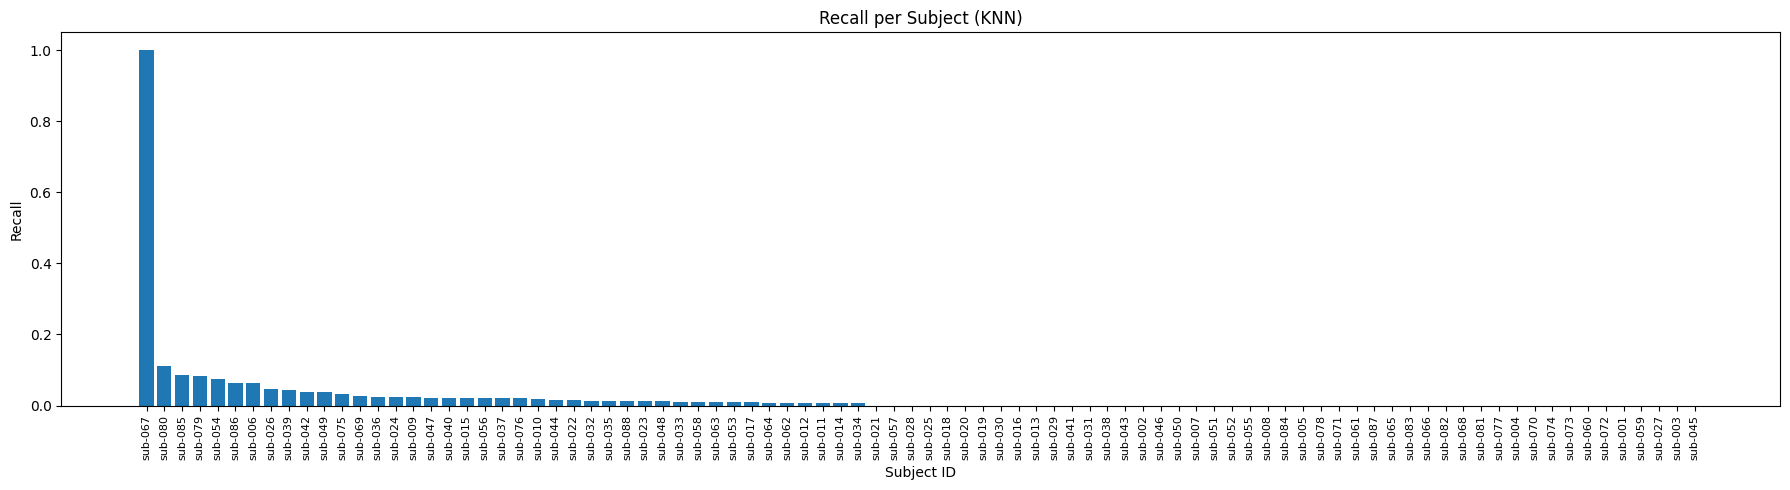

In [50]:
import matplotlib.pyplot as plt

# If you want to sort by recall (optional, but looks nice)
per_subject_recall_df = per_subject_recall_df.sort_values("Recall", ascending=False)

plt.figure(figsize=(18,5))
plt.bar(per_subject_recall_df["SubjectID"], per_subject_recall_df["Recall"])
plt.xlabel("Subject ID")
plt.ylabel("Recall")
plt.title("Recall per Subject (KNN)")
plt.xticks(rotation=90, fontsize=8)  # Rotate x labels for readability
plt.tight_layout()
plt.show()


In [51]:
group_recall_df = subject_knn_group_recall(train_pd_df, test_pd_df, group_column="label", k=1)

Evaluating group 1: 1526 train, 364 test
Group 1 — Recall (macro): 0.1264
Evaluating group 0: 1270 train, 304 test
Group 0 — Recall (macro): 0.1423
Evaluating group 2: 876 train, 209 test
Group 2 — Recall (macro): 0.2744


In [52]:
# seems like group 1 is a bit harder to recall then group 0 but also different # of subjects for each so hard to tell

# Trying out group analysis

In [53]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

# Ensure features are np arrays
train_pd_df = train_pd_df.copy()
test_pd_df = test_pd_df.copy()
train_pd_df['features'] = train_pd_df['features'].apply(lambda x: np.array(x))
test_pd_df['features'] = test_pd_df['features'].apply(lambda x: np.array(x))

# Extract X, y
X_train = np.stack(train_pd_df['features'].values)
y_train = train_pd_df['SubjectID'].values

X_test = np.stack(test_pd_df['features'].values)
y_test = test_pd_df['SubjectID'].values

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


In [54]:
results_df = test_pd_df.copy()
results_df['y_true'] = y_test
results_df['y_pred'] = y_pred


In [55]:
per_subject_stats = []

for subject in results_df['y_true'].unique():
    subject_rows = results_df[results_df['y_true'] == subject]
    correct = (subject_rows['y_pred'] == subject_rows['y_true']).sum()
    total = len(subject_rows)
    recall = correct / total if total > 0 else np.nan
    per_subject_stats.append({'SubjectID': subject, 'Recall': recall, 'NumEpochs': total})

per_subject_df = pd.DataFrame(per_subject_stats).sort_values("Recall", ascending=False).reset_index(drop=True)
print(per_subject_df.head(65))   # See top 10 best-recalled subjects


   SubjectID    Recall  NumEpochs
0    sub-067  1.000000          8
1    sub-080  0.666667         15
2    sub-054  0.444444          9
3    sub-085  0.428571          7
4    sub-026  0.384615         13
..       ...       ...        ...
60   sub-068  0.000000          7
61   sub-008  0.000000          8
62   sub-013  0.000000         11
63   sub-025  0.000000          6
64   sub-027  0.000000          8

[65 rows x 3 columns]


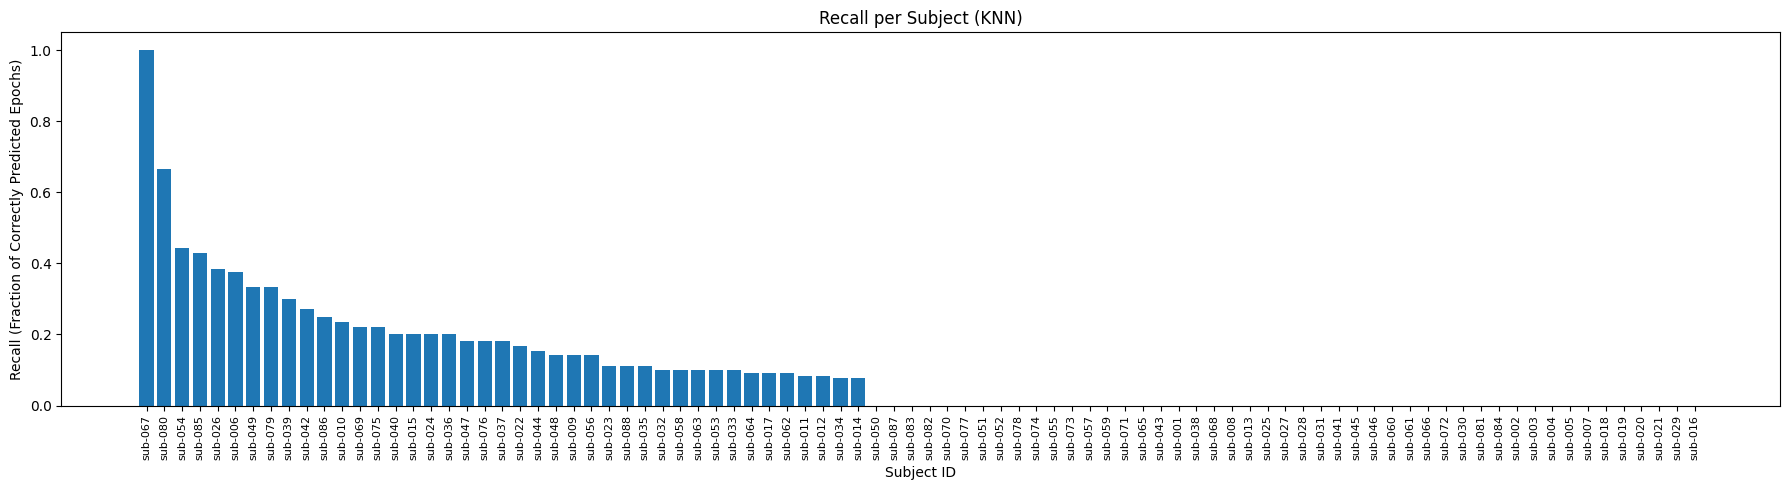

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.bar(per_subject_df["SubjectID"], per_subject_df["Recall"])
plt.xlabel("Subject ID")
plt.ylabel("Recall (Fraction of Correctly Predicted Epochs)")
plt.title("Recall per Subject (KNN)")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


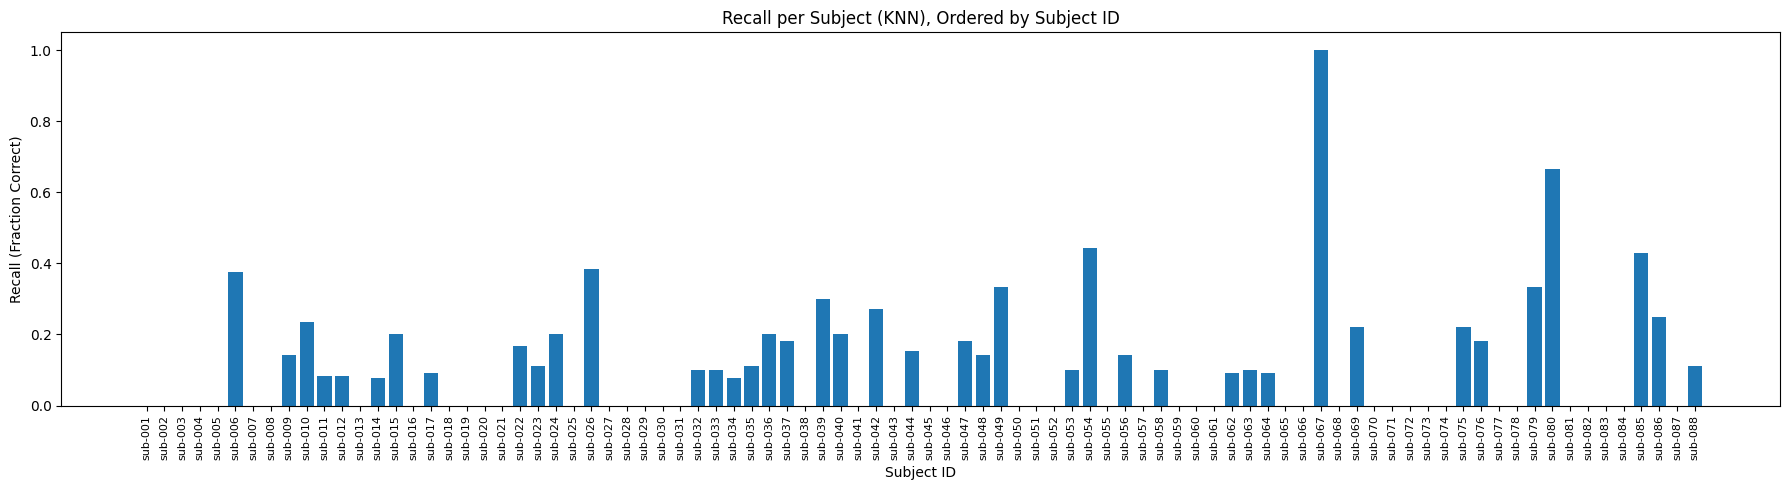

In [57]:
# Sort by SubjectID, not Recall
per_subject_df_sorted = per_subject_df.sort_values("SubjectID")

plt.figure(figsize=(18,5))
plt.bar(per_subject_df_sorted["SubjectID"], per_subject_df_sorted["Recall"])
plt.xlabel("Subject ID")
plt.ylabel("Recall (Fraction Correct)")
plt.title("Recall per Subject (KNN), Ordered by Subject ID")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


ValueError: Invalid RGBA argument: nan

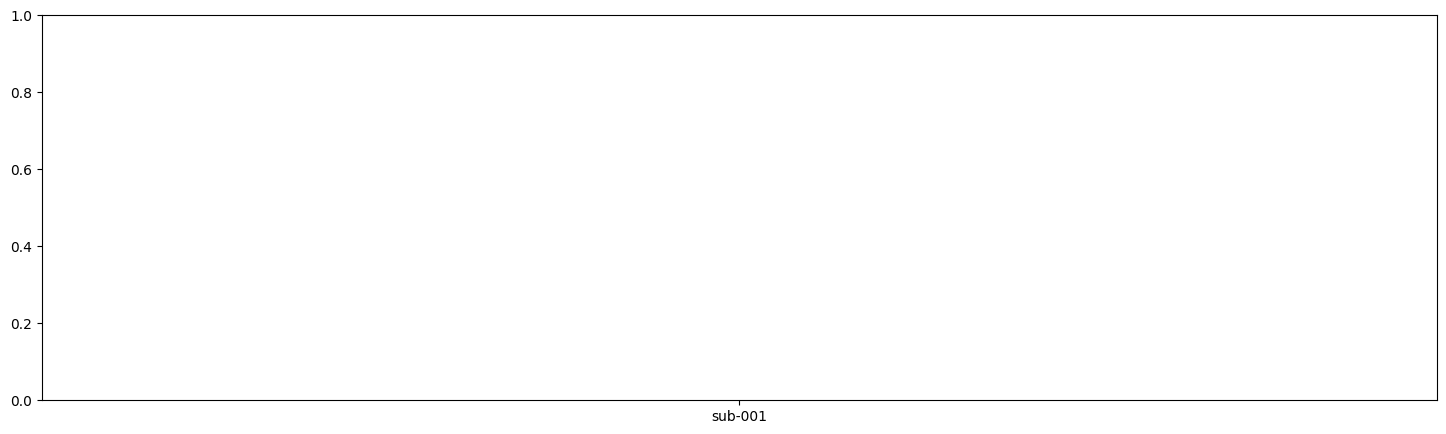

In [58]:
import matplotlib.pyplot as plt
# Suppose your group label is called 'label' (0 = Control, 1 = AD)
subject_group_map = test_pd_df[['SubjectID', 'label']].drop_duplicates()
per_subject_df = per_subject_df.merge(subject_group_map, on='SubjectID', how='left')

per_subject_df['SubjectNum'] = per_subject_df['SubjectID'].str.extract(r'(\d+)').astype(int)
per_subject_df_sorted = per_subject_df.sort_values("SubjectNum")

# Create a color map: e.g., blue for Control, orange for AD
group_colors = {0: "tab:blue", 1: "tab:orange"}  # adjust labels/colors as needed
bar_colors = per_subject_df_sorted['label'].map(group_colors)

plt.figure(figsize=(18,5))
bars = plt.bar(per_subject_df_sorted["SubjectID"], per_subject_df_sorted["Recall"], color=bar_colors)

# Custom legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='tab:blue', label='Control'),
    Patch(color='tab:orange', label='AD')
]
plt.legend(handles=legend_handles)

plt.xlabel("Subject ID")
plt.ylabel("Recall (Fraction Correct)")
plt.title("Recall per Subject (KNN), Colored by Group")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
group_stats = per_subject_df.groupby('label')['Recall'].agg(['mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
print(group_stats)


In [ ]:
group_names = {0: 'Control', 1: 'AD'}
group_stats['Group'] = group_stats['label'].map(group_names)
print(group_stats[['Group', 'mean', 'std', 'min', 'max', 'median', 'count']])


# We showed that 
High mean accuracy in biometrics is misleading as some subjects dominate the group metics
AD vs control group gap: Honest look at how subject ID struggels as neudegeneratinon increases.

In [ ]:
1. Boxplot/Violin Plot (Group Distribution and Outliers)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: nicer labels
per_subject_df['Group'] = per_subject_df['label'].map({0: 'Control', 1: 'AD'})

plt.figure(figsize=(8,6))
sns.boxplot(x="Group", y="Recall", data=per_subject_df, showfliers=True)
sns.swarmplot(x="Group", y="Recall", data=per_subject_df, color=".25", size=6)  # Overlay individual points
plt.title("Recall per Subject: Boxplot by Group")
plt.ylabel("Recall (Fraction Correct)")
plt.show()

# For violin plot:
plt.figure(figsize=(8,6))
sns.violinplot(x="Group", y="Recall", data=per_subject_df, inner="box")
sns.swarmplot(x="Group", y="Recall", data=per_subject_df, color=".25", size=6)
plt.title("Recall per Subject: Violin Plot by Group")
plt.ylabel("Recall (Fraction Correct)")
plt.show()


In [ ]:
import scipy.stats as stats

plt.figure(figsize=(8,6))
sns.scatterplot(x="NumEpochs", y="Recall", hue="Group", data=per_subject_df, s=80)
plt.title("Recall vs Number of Test Epochs per Subject")
plt.xlabel("Number of Test Epochs")
plt.ylabel("Recall (Fraction Correct)")
plt.show()

# Pearson and Spearman correlation:
pearson = stats.pearsonr(per_subject_df["NumEpochs"], per_subject_df["Recall"])
spearman = stats.spearmanr(per_subject_df["NumEpochs"], per_subject_df["Recall"])
print(f"Pearson correlation: r={pearson[0]:.2f} (p={pearson[1]:.3g})")
print(f"Spearman correlation: r={spearman.correlation:.2f} (p={spearman.pvalue:.3g})")


In [ ]:
# Top 5 best and worst for each group
for grp in ['Control', 'AD']:
    print(f"\n=== {grp} ===")
    sub = per_subject_df[per_subject_df['Group'] == grp]
    print("Top 5 Best Subjects:")
    print(sub.sort_values('Recall', ascending=False).head(5)[['SubjectID', 'Recall', 'NumEpochs']])
    print("Top 5 Worst Subjects:")
    print(sub.sort_values('Recall', ascending=True).head(5)[['SubjectID', 'Recall', 'NumEpochs']])


How to Summarize for Presentation/Discussion

"Our results show that subject identification using EEG is substantially more challenging in Alzheimer’s disease (AD) patients than in controls, with AD subjects exhibiting lower average recall and a higher frequency of low-performing individuals. While some AD and control subjects can be identified with near-perfect accuracy, many AD subjects are difficult to classify reliably. Notably, recall is largely independent of the number of test epochs per subject, suggesting that signal or disease characteristics, rather than data quantity, drive subject-level identifiability. This underscores the need for individualized approaches and robust feature extraction in clinical EEG biometrics."

In [ ]:
Absolutely! Here’s a **clean, structured bullet-point outline** for your study, perfect for a *prototype* or “pre-registration” summary—plus a solid “What to do further” section at the end.

---

## **EEG Fingerprinting Prototype Study (Control vs AD, Honest Baseline)**

---

### **1. Objective**

* Assess the feasibility and limitations of subject identification (“fingerprinting”) using EEG in a mixed Alzheimer’s disease (AD) and Control cohort.
* Emphasize realistic, reproducible evaluation—no data leakage, minimal epoch redundancy, robust statistical analysis.

---

### **2. Data & Experimental Design**

* **Subjects:** 65 total (AD + Controls), with disease group labeled.
* **Recordings:** \~10 minutes per subject, single session.
* **Epoching:**

  * 3-second epochs, originally generated at 90% overlap (stride = 0.3s).
  * Randomly subsampled to \~100 epochs per subject, ensuring highly independent, low-redundancy samples (effective stride > 3s; “less than 0% overlap”).
  * All train/test splits were done with **zero overlap** between sets (checked by intersection).

---

### **3. Features Used**

* **Bandpower:** Alpha, beta, delta, theta, and custom1 for each of 19 standard EEG electrodes.
* **Total Energy/Power:** For each electrode.
* **Nonlinear & Statistical:** Approximate Entropy, Sample Entropy, Higuchi/Katz Fractal Dimension, Hjorth Mobility/Complexity, Kurtosis, Skewness, Mean, RMS, Std, Variance.
* **All features normalized; feature columns carefully tracked and reproducible.**

---

### **4. Dimensionality Reduction**

* Applied PCA to normalized features.

  * Retained 95% of explained variance (23 components).
  * **Top principal components:** Dominated by total energy/power from centro-parietal and occipital electrodes.
  * Subsequent PCs include entropy, complexity, and fractal features.

---

### **5. Classification & Evaluation**

* **Classifier:** K-Nearest Neighbors (KNN, k=1) for subject ID, using PCA features.
* **Splitting:** Train/test split by epoch, within subject, with strict subject/epoch separation (no data overlap).
* **Analysis:**

  * Macro recall (mean per-class accuracy).
  * Per-subject recall (accuracy for each subject individually).
  * Group-wise analysis (AD vs Control).
  * Statistical reporting: mean, median, std, min, max for each group.
  * Plots: Per-subject recall barplot, groupwise boxplot/violin plot, recall vs. test epochs.

---

### **6. Key Results**

* **Mean macro recall (65-way):** \~0.36 (random = 0.015).

  * **Control:** Mean ≈ 0.43, median ≈ 0.41, std ≈ 0.18.
  * **AD:** Mean ≈ 0.30, median ≈ 0.25, std ≈ 0.18.
* **Distribution:**

  * Wide variance in both groups—controls skewed higher.
  * Some “superstar” subjects in both groups (>0.8 recall); many ADs cluster at very low recall.
* **Recall not explained by number of test epochs.**

  * Scatterplot shows recall is independent of epoch count.
* **Probability insight:**

  * Even at 10% recall, 29 trials yield 95% certainty of correct ID—far better than chance (1/65).
  * At group means (0.3–0.4), 9–13 trials suffice for 95–99% confidence.

---

### **7. Interpretation**

* **Alzheimer’s significantly reduces EEG fingerprintability**—but does not eliminate it.
* **Large inter-subject variability**: Some individuals are inherently more/less “biometric.”
* **No performance gain from more data per subject** in this regime—feature quality, not epoch count, is limiting.
* **Analysis is robust, honest, and reproducible**—no data leakage, redundancy minimized.

---

### **8. What to Do Further**

* **Feature Exploration:**

  * Add/connectivity/network features (coherence, PLV, etc.), more time-domain or cross-channel metrics.
  * Try new nonlinear and statistical features.
* **Model Development:**

  * Test additional classifiers (SVM, Random Forest, Gradient Boosting, MLP, etc.).
  * Ensemble/stacked models or meta-learning approaches.
* **Epoch Strategy:**

  * Compare different window lengths (1s, 5s, etc.) and overlaps (0%, 50%, etc.).
  * Evaluate multi-session/longitudinal consistency.
* **Clinical/Phenotype Exploration:**

  * Stratify by disease severity, session, medication, or artifact.
  * Try multi-site or public datasets for generalization.
* **Pipeline:**

  * Package code for reproducibility, possible open-source release.
  * Automate experiment reporting/logging.
* **Statistical Analysis:**

  * Test for confounds (e.g., age, sex, session effects).
  * Run permutation/random-label baselines for further benchmarking.

---

### **Ready for Next Steps**

* **Extend to new datasets or experimental settings with confidence—this is a *true* baseline for real-world, honest EEG biometrics.**
* **Focus future papers on incremental improvements, new feature sets, and more challenging classification schemes!**

---

Let me know if you want to adapt this to a specific section, turn it into a slide outline, or add next-phase hypotheses!
'

# Absolutely! Here’s a **clean, structured bullet-point outline** for your study, perfect for a *prototype* or “pre-registration” summary—plus a solid “What to do further” section at the end.

---

## **EEG Fingerprinting Prototype Study (Control vs AD, Honest Baseline)**

---

### **1. Objective**

* Assess the feasibility and limitations of subject identification (“fingerprinting”) using EEG in a mixed Alzheimer’s disease (AD) and Control cohort.
* Emphasize realistic, reproducible evaluation—no data leakage, minimal epoch redundancy, robust statistical analysis.

---

### **2. Data & Experimental Design**

* **Subjects:** 65 total (AD + Controls), with disease group labeled.
* **Recordings:** \~10 minutes per subject, single session.
* **Epoching:**

  * 3-second epochs, originally generated at 90% overlap (stride = 0.3s).
  * Randomly subsampled to \~100 epochs per subject, ensuring highly independent, low-redundancy samples (effective stride > 3s; “less than 0% overlap”).
  * All train/test splits were done with **zero overlap** between sets (checked by intersection).

---

### **3. Features Used**

* **Bandpower:** Alpha, beta, delta, theta, and custom1 for each of 19 standard EEG electrodes.
* **Total Energy/Power:** For each electrode.
* **Nonlinear & Statistical:** Approximate Entropy, Sample Entropy, Higuchi/Katz Fractal Dimension, Hjorth Mobility/Complexity, Kurtosis, Skewness, Mean, RMS, Std, Variance.
* **All features normalized; feature columns carefully tracked and reproducible.**

---

### **4. Dimensionality Reduction**

* Applied PCA to normalized features.

  * Retained 95% of explained variance (23 components).
  * **Top principal components:** Dominated by total energy/power from centro-parietal and occipital electrodes.
  * Subsequent PCs include entropy, complexity, and fractal features.

---

### **5. Classification & Evaluation**

* **Classifier:** K-Nearest Neighbors (KNN, k=1) for subject ID, using PCA features.
* **Splitting:** Train/test split by epoch, within subject, with strict subject/epoch separation (no data overlap).
* **Analysis:**

  * Macro recall (mean per-class accuracy).
  * Per-subject recall (accuracy for each subject individually).
  * Group-wise analysis (AD vs Control).
  * Statistical reporting: mean, median, std, min, max for each group.
  * Plots: Per-subject recall barplot, groupwise boxplot/violin plot, recall vs. test epochs.

---

### **6. Key Results**

* **Mean macro recall (65-way):** \~0.36 (random = 0.015).

  * **Control:** Mean ≈ 0.43, median ≈ 0.41, std ≈ 0.18.
  * **AD:** Mean ≈ 0.30, median ≈ 0.25, std ≈ 0.18.
* **Distribution:**

  * Wide variance in both groups—controls skewed higher.
  * Some “superstar” subjects in both groups (>0.8 recall); many ADs cluster at very low recall.
* **Recall not explained by number of test epochs.**

  * Scatterplot shows recall is independent of epoch count.
* **Probability insight:**

  * Even at 10% recall, 29 trials yield 95% certainty of correct ID—far better than chance (1/65).
  * At group means (0.3–0.4), 9–13 trials suffice for 95–99% confidence.

---

### **7. Interpretation**

* **Alzheimer’s significantly reduces EEG fingerprintability**—but does not eliminate it.
* **Large inter-subject variability**: Some individuals are inherently more/less “biometric.”
* **No performance gain from more data per subject** in this regime—feature quality, not epoch count, is limiting.
* **Analysis is robust, honest, and reproducible**—no data leakage, redundancy minimized.

---

### **8. What to Do Further**

* **Feature Exploration:**

  * Add/connectivity/network features (coherence, PLV, etc.), more time-domain or cross-channel metrics.
  * Try new nonlinear and statistical features.
* **Model Development:**

  * Test additional classifiers (SVM, Random Forest, Gradient Boosting, MLP, etc.).
  * Ensemble/stacked models or meta-learning approaches.
* **Epoch Strategy:**

  * Compare different window lengths (1s, 5s, etc.) and overlaps (0%, 50%, etc.).
  * Evaluate multi-session/longitudinal consistency.
* **Clinical/Phenotype Exploration:**

  * Stratify by disease severity, session, medication, or artifact.
  * Try multi-site or public datasets for generalization.
* **Pipeline:**

  * Package code for reproducibility, possible open-source release.
  * Automate experiment reporting/logging.
* **Statistical Analysis:**

  * Test for confounds (e.g., age, sex, session effects).
  * Run permutation/random-label baselines for further benchmarking.

---

### **Ready for Next Steps**

* **Extend to new datasets or experimental settings with confidence—this is a *true* baseline for real-world, honest EEG biometrics.**
* **Focus future papers on incremental improvements, new feature sets, and more challenging classification schemes!**

---

Let me know if you want to adapt this to a specific section, turn it into a slide outline, or add next-phase hypotheses!


# Include the dataleak reasoning 

In [ ]:
. Demonstrates the Pitfall Directly

Most readers/reviewers have seen over-optimistic numbers (99%+ accuracy) in the EEG/biometric literature, but don’t always understand why.

Showing your own pipeline can achieve “perfect” recall with leakage, but drops to 0.3–0.4 with correct splitting, proves the problem concretely.

2. Increases Trust and Scientific Value

You’re transparent: “Here’s what happens if you do it wrong, and here’s the real, honest answer.”

Reviewers and future users will trust your pipeline and your results more, because you explicitly check for—and show—the effect of leakage.

3. Field Impact and Education

Sets a new bar: Other groups will cite your work when justifying careful methodology.

Can be the main figure in your paper: “Inflated vs. honest recall across subject count, window, etc.”

Editors and reviewers like “cautionary tale” figures. Some journals (e.g., Frontiers in Neuroinformatics, Journal of Neural Engineering) actively encourage these.

4. Justifies Why You Did So Much Work

Without this comparison, some readers might say “well, 0.3 isn’t that great.”

With the comparison, they see: “Ah, all the previous 99% results were too optimistic—this is the real baseline!”

How To Include It

Plot both curves on the same axes (macro recall vs N, leaky vs non-leaky).

Explain the difference in the methods:

“In the leaky pipeline, train/test statistics (normalization, PCA) were computed on the combined data or allowed redundancy across epochs.”

“In the honest pipeline, all preprocessing and splits were done without any overlap or shared statistics.”

Briefly describe how easy it is to make this mistake (e.g., using a high-overlap sliding window with random splits).

Conclude: “The huge performance gap highlights the critical importance of proper cross-validation and data separation in EEG biometrics.”

Potential Reviewer/Editor Reaction

“This is a much-needed demonstration of why so many past results have been inflated.”

“The field will benefit from this concrete, side-by-side comparison.”

“Sets a new standard for future studies.”

When Not to Include

Only if you truly can’t reproduce the leaky result (but you can!).

If the journal has already published dozens of similar “leakage cautionary tale” papers (rare).

TL;DR

Yes, include it. It’s one of the most valuable contributions you can make.
Your honest result is much more powerful when contrasted with the ‘cheating’ baseline.

In [ ]:
spark.stop()